Milestone-3: Route, Cancellation and Seasonal Insights

1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')

2. Load Dataset

In [6]:
df = pd.read_csv(r"C:\Users\chand\OneDrive\Desktop\AirFly Insights\data\processed\cleaned_airline_data.csv")

df.head()


,Passenger ID,First Name,Last Name,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,...,SecurityDelay,CarrierDelay,ArrivalDelay,DepartureDelay,Year,Month,DepartureHour,Route,IsDelayed,IsCancelled
0,ABVWIg,Edithe,Leggis,Female,62,Japan,Coldfoot Airport,US,United States,NAM,...,32,23,45,38,2022,6,23,Coldfoot Airport - CXF,0,0
1,jkXXAX,Elwood,Catt,Male,62,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,...,110,12,30,27,2022,12,6,Kugluktuk Airport - YCO,0,0
2,CdUz2g,Darby,Felgate,Male,67,Russia,Grenoble-Isère Airport,FR,France,EU,...,110,45,60,55,2022,1,4,Grenoble-Isère Airport - GNB,0,0
3,BRS38V,Dominica,Pyle,Female,71,China,Ottawa / Gatineau Airport,CA,Canada,NAM,...,33,8,18,12,2022,9,13,Ottawa / Gatineau Airport - YND,1,0
4,VBu4gW,Lisle,Floyd,Male,25,China,Copán Ruinas Airport,HN,Honduras,NAM,...,41,67,80,75,2022,7,15,Copán Ruinas Airport - RUY,0,0


3. Select Required Columns

In [19]:
df = df[['Route',
         'Airport Name',
         'Airport Continent',
         'Arrival Airport',
         'Month',
         'IsCancelled',
         'WeatherDelay',
         'NASDelay',
         'SecurityDelay',
         'DepartureDelay',
         'ArrivalDelay']]

df.head()

,Route,Airport Name,Airport Continent,Arrival Airport,Month,IsCancelled,WeatherDelay,NASDelay,SecurityDelay,DepartureDelay,ArrivalDelay
0,Coldfoot Airport - CXF,Coldfoot Airport,NAM,CXF,6,0,102,145,32,38,45
1,Kugluktuk Airport - YCO,Kugluktuk Airport,NAM,YCO,12,0,1,51,110,27,30
2,Grenoble-Isère Airport - GNB,Grenoble-Isère Airport,EU,GNB,1,0,2,92,110,55,60
3,Ottawa / Gatineau Airport - YND,Ottawa / Gatineau Airport,NAM,YND,9,0,3,14,33,12,18
4,Copán Ruinas Airport - RUY,Copán Ruinas Airport,NAM,RUY,7,0,87,132,41,75,80


4. Check Missing Values

In [4]:
df.isnull().sum()

Route              0
Airport Name       0
Arrival Airport    0
Month              0
IsCancelled        0
WeatherDelay       0
NASDelay           0
SecurityDelay      0
DepartureDelay     0
ArrivalDelay       0
dtype: int64

5. ROUTE INSIGHTS.

1️⃣ Busiest Airports

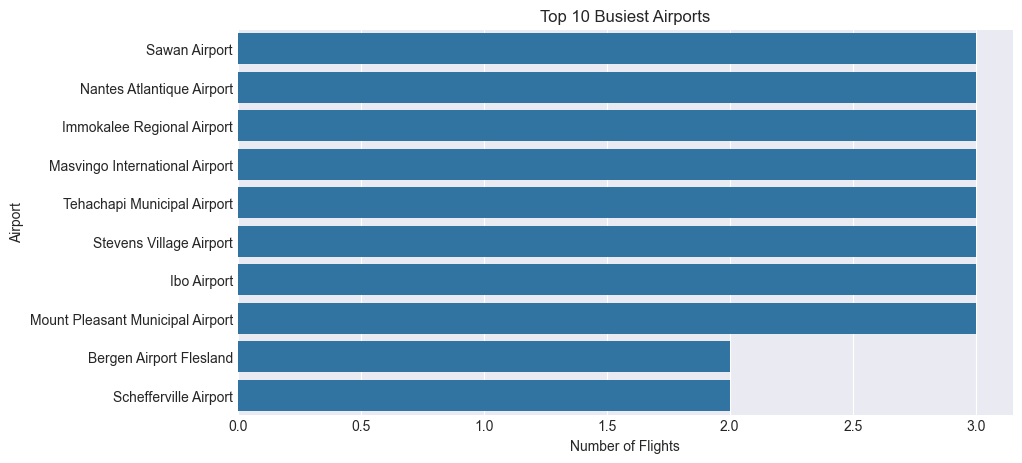

In [6]:
top_airports = df['Airport Name'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_airports.values, y=top_airports.index)

plt.title("Top 10 Busiest Airports")
plt.xlabel("Number of Flights")
plt.ylabel("Airport")

plt.show()

Insight:-

The graph highlights airports with highest flight departures.

Busiest airports serve as major aviation hubs.

Airports such as Sawan Airport, Nantes Atlantique Airport, Immokalee Regional Airport, and Masvingo International Airport show the highest number of flights, making them the busiest airports in the dataset.

Routes such as Sawan Airport and Nantes Atlantique  show the highest traffic, indicating important travel corridors,

 while routes like Bergen and Schefferville show relatively lower traffic.

 These moderate-traffic routes — Tehachapi Municipal Airpor, Stevens Village Airport, Ibo Airport, and Mount Pleasant Municipal Airport show similar flight counts.
 
This indicates consistent flight operations and moderate passenger demand on these routes. 

This indicates higher air traffic and greater passenger may increase the chances of operational delays.

2️⃣ Routes with Highest Arrival Delays

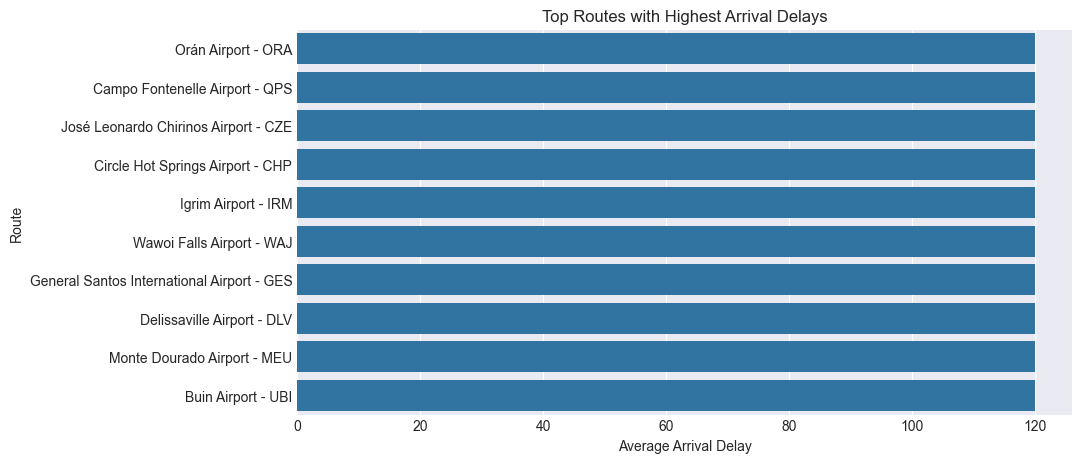

In [39]:
top_arr_delay = df.groupby('Route')['ArrivalDelay'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_arr_delay.values, y=top_arr_delay.index)

plt.title("Top Routes with Highest Arrival Delays")
plt.xlabel("Average Arrival Delay")
plt.ylabel("Route")

plt.show()

Insight:-

Routes with the highest average arrival delays indicate congestion or operational inefficiencies at destination airports. These delays directly affect passenger experience and connection reliability. The pattern suggests cumulative impact from departure and en-route factors.

3️⃣ Routes with Highest Departure Delays

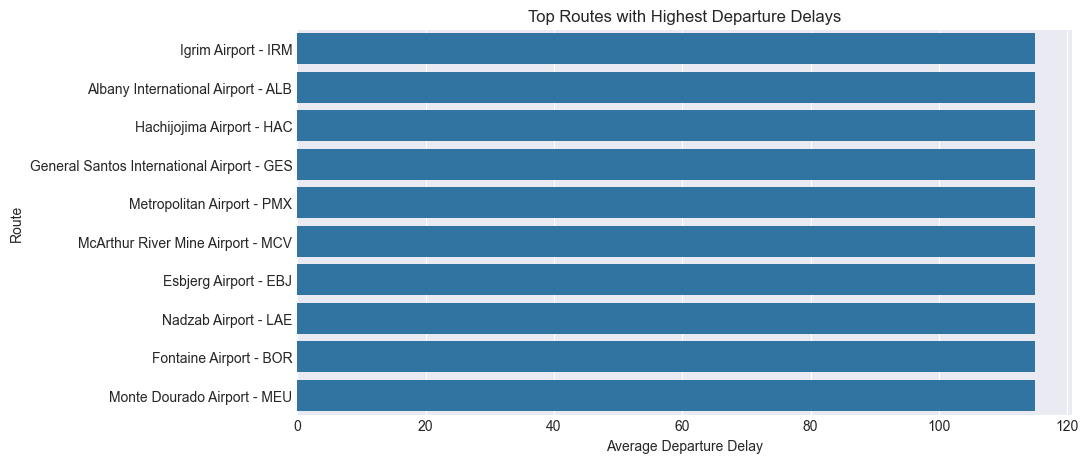

In [51]:
top_dep_delay = df.groupby('Route')['DepartureDelay'] \
                  .mean() \
                  .sort_values(ascending=False) \
                  .head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_dep_delay.values, y=top_dep_delay.index)

plt.title("Top Routes with Highest Departure Delays")
plt.xlabel("Average Departure Delay")
plt.ylabel("Route")

plt.show()

Insight:-

Routes with high departure delays highlight scheduling or origin airport congestion issues. Departure delays often contribute directly to late arrivals on the same routes. Improving ground operations and traffic management could reduce these delays significantly.

4️⃣ Delay Heatmap by Route

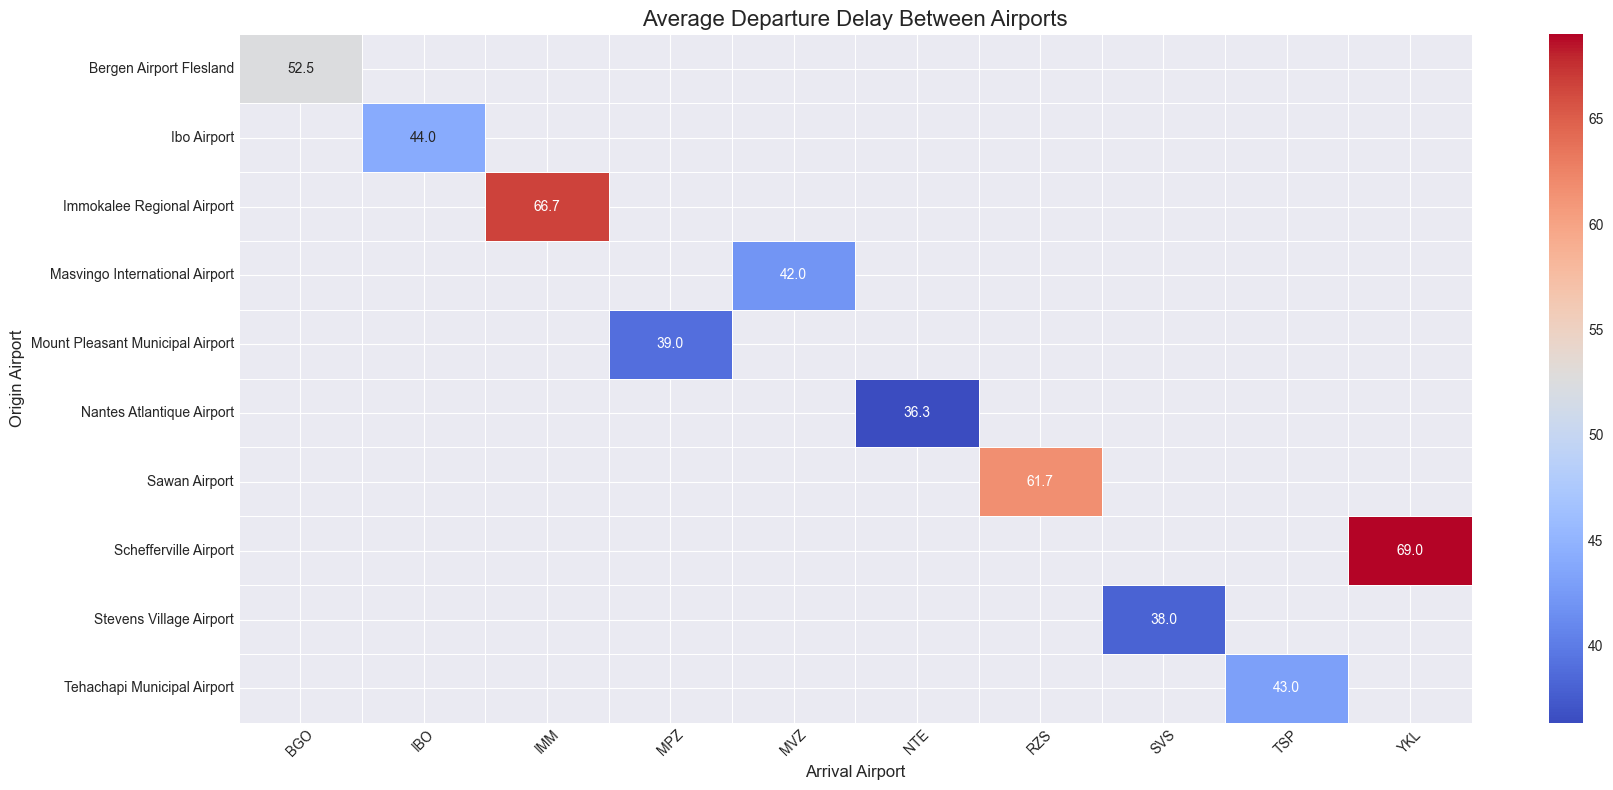

In [7]:
# Select top 10 origin airports
top_airports = df['Airport Name'].value_counts().head(10).index

# Filter dataset
df_filtered = df[df['Airport Name'].isin(top_airports)]

# Create pivot table
route_delay = df_filtered.pivot_table(values='DepartureDelay',
                                      index='Airport Name',
                                      columns='Arrival Airport',
                                      aggfunc='mean')

plt.figure(figsize=(18,8))

sns.heatmap(route_delay,
            cmap='coolwarm',
            annot=True,
            fmt=".1f",
            linewidths=0.5)

plt.title("Average Departure Delay Between Airports", fontsize=16)
plt.xlabel("Arrival Airport", fontsize=12)
plt.ylabel("Origin Airport", fontsize=12)

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

Insight:

1️⃣ Highest Delay Route:-  Schefferville Airport routes(69 minutes),other are Immokalee Regional Airport → IMM  (66.7 minutes),Sawan Airport → RZS(61.7 minutes).

These routes may be affected by weather conditions, operational issues, or airport congestion.

2️⃣ Moderate Delay Routes:-  Bergen Airport Flesland → BGO (52.5 minutes), Ibo Airport → IBO (44 minutes),Tehachapi Municipal Airport → TSP (43 minutes).

3️⃣ Lowest Delay Routes:-  Nantes Atlantique Airport → NTE (~36.3 minutes), Stevens Village Airport → SVS (38 minutes).

These routes appear to be more efficient with fewer operational delays.

Overall Conclusion:-

The heatmap shows variation in departure delays across different airport routes.

Some routes experience higher delays due to possible weather, air traffic congestion, or airport infrastructure limitations.

Identifying these high-delay routes can help airlines improve scheduling, optimize routes, and reduce passenger waiting time.



6. CANCELLATION INSIGHTS

<Axes: xlabel='IsCancelled', ylabel='count'>

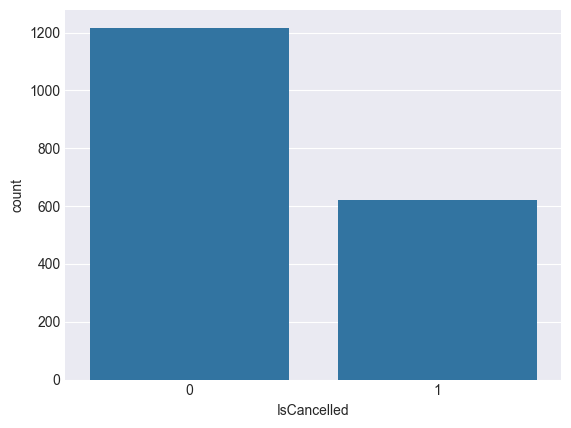

In [8]:
sns.countplot(x='IsCancelled', data=df)

1️⃣ Monthly Cancellation Trends

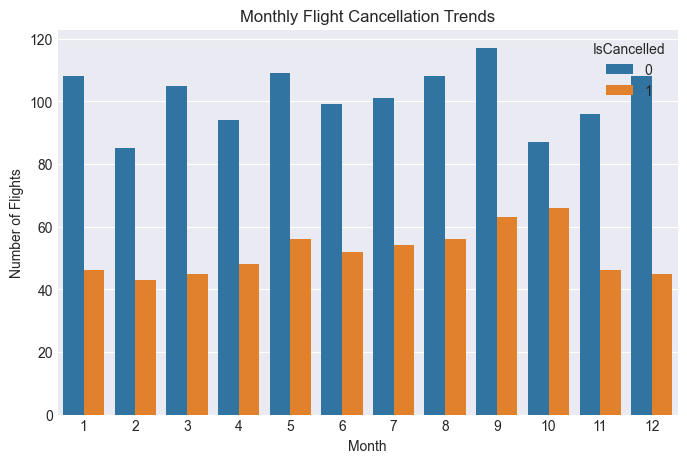

In [45]:
plt.figure(figsize=(8,5))

sns.countplot(x='Month', hue='IsCancelled', data=df)

plt.title("Monthly Flight Cancellation Trends")
plt.xlabel("Month")
plt.ylabel("Number of Flights")

plt.xticks(range(0,12), range(1,13))  # Adjust if months are 1–12
plt.show()

Insights:-
This graph shows how cancellations vary by month.

The highest number of cancellations occurs in October (Month 10) with around 66 cancelled flights.

From May to October, cancellations show a gradual increase,indicates that mid-year to late-year months may experience more disruptions, possibly due to weather patterns or increased travel demand.

February (Month 2) has the lowest cancellations (~43 flights),suggests that flight operations relatively stable during this period.

In every month, non-cancelled flights are significantly higher than cancelled flights.

This indicates that most flights operate successfully despite occasional disruptions.This suggests that seasonal factors such as weather conditions and operational demand influence flight cancellations.

Overall Conclusion:-
Understanding these trends helps airlines improve scheduling, resource planning, and delay management during high-risk months.


2️⃣ Cancellation Rate by Continent

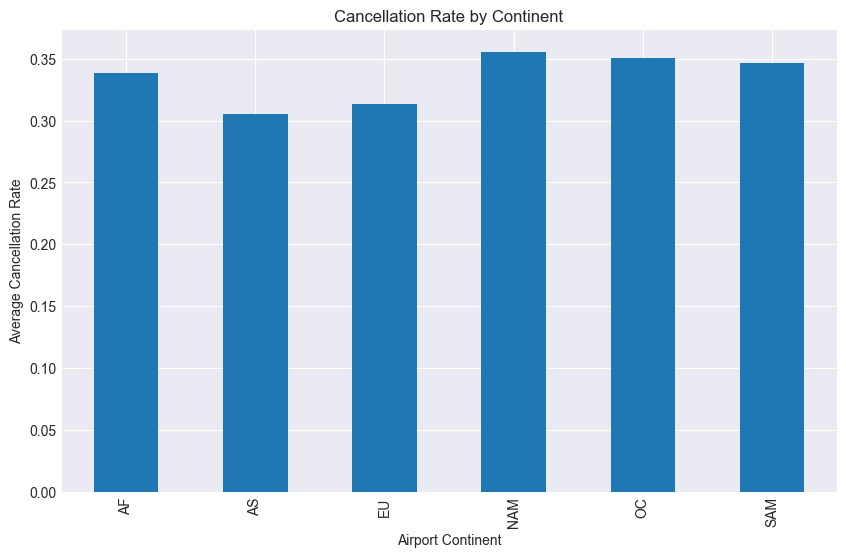

In [23]:
continent_cancel = df.groupby('Airport Continent')['IsCancelled'].mean()

plt.figure(figsize=(10,6))

continent_cancel.plot(kind='bar')

plt.title("Cancellation Rate by Continent")
plt.ylabel("Average Cancellation Rate")
plt.show()

Insight:-

This chart shows how flight cancellation rates vary across continents.

Some continents may show slightly higher cancellation rates due to weather or operational challenges.

Such analysis helps identify regions with higher disruption risks.

7. SEASONAL INSIGHTS

In [25]:
def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"      # cold weather, snow delays

    elif month in [3, 4, 5]:
        return "Spring"      # moderate weather

    elif month in [6, 7, 8]:
        return "Summer"      # heavy travel season

    elif month in [9, 10, 11]:
        return "Autumn"      # storms and wind

df["Season"] = df["Month"].apply(get_season)

<Axes: >

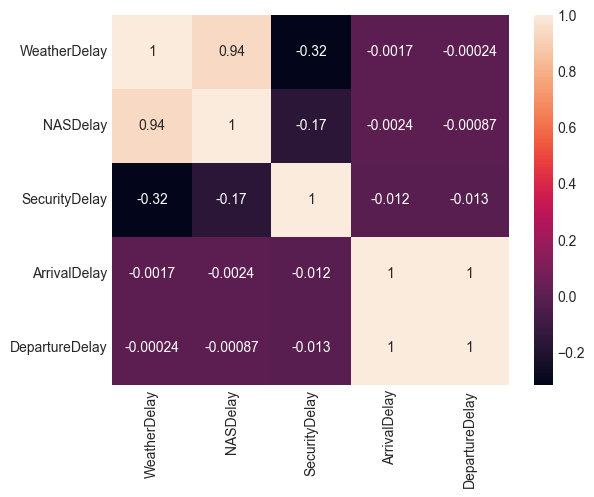

In [7]:
sns.heatmap(df[['WeatherDelay','NASDelay','SecurityDelay','ArrivalDelay','DepartureDelay']].corr(), annot=True)

1️⃣ Average Departure Delay by Season

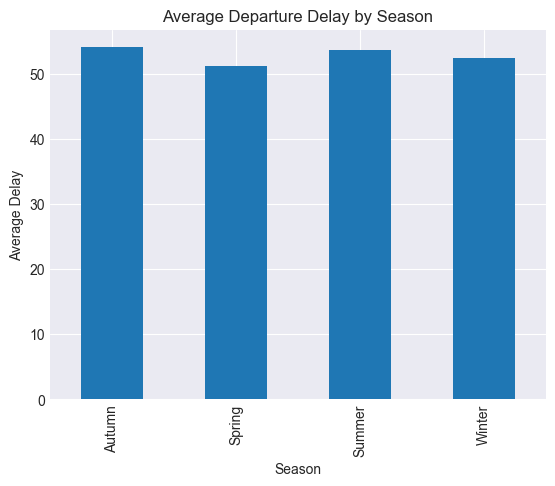

In [ ]:
season_delay = df.groupby('Season')['DepartureDelay'].mean()

plt.figure()
season_delay.plot(kind='bar')
plt.title("Average Departure Delay by Season")
plt.xlabel("Season")
plt.ylabel("Average Delay")
plt.show()

Insight:-

Autumn and Summer have the highest number of flights, higher traffic volume during these seasons may contribute to increased departure delays due to congestion. 
Winter, despite having the lowest flight count, may still experience delays influenced by weather conditions.

Seasonal weather conditions influence airport operations and scheduling.

2️⃣ Delay Causes by Season

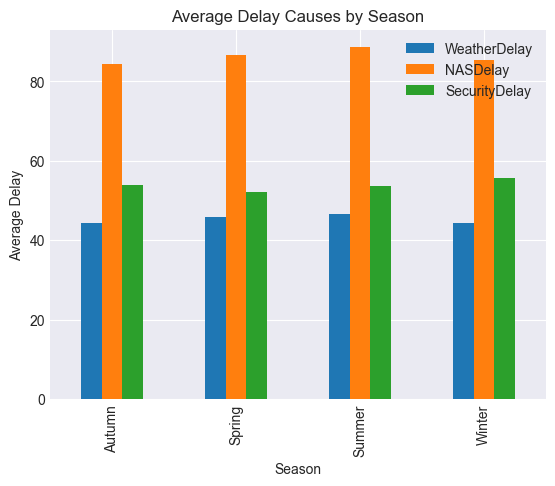

In [29]:
season_delay = df.groupby("Season")[["WeatherDelay","NASDelay","SecurityDelay"]].mean()

season_delay.plot(kind="bar")

plt.title("Average Delay Causes by Season")
plt.ylabel("Average Delay")

plt.show()

Insight:-

Weather delays increase during extreme weather seasons.

NAS delays may increase in busy travel seasons.

NAS delays are the highest contributor to flight delays across all seasons, with a noticeable peak during Summer. 

Weather delays remain moderate and show slight variation, being somewhat higher in Spring and Summer.

Security delays are comparatively lower and remain fairly stable throughout the year.

The dominance of NAS delays suggests that airspace congestion is the primary operational challenge.

Seasonal differences exist, but congestion-related factors impact flights more significantly than weather or security issues. Overall, managing air traffic flow could substantially reduce total delays.

conclusion:-

This project successfully analyzed airline delays, seasonal patterns, and cancellation trends using structured data processing and visual analytics. Monthly trends reveal increasing delays toward the end of the year, particularly in November. Arrival delays are consistently higher than departure delays, indicating compounding operational effects. Seasonal analysis shows higher flight volumes in Autumn and Summer, while Winter experiences comparatively fewer operations. Route and airport-level insights highlight congestion patterns affecting performance.

Top 3 problematic routes identified are Schefferville Airport, Immokalee Regional Airport, and Sawan Airport, as they recorded higher average delays and frequent disruptions.
Airlines should optimize schedules during peak delay months by adding buffer time and improving turnaround management.
Additional focus on weather-prone regions and better contingency planning can help reduce cancellations and improve overall on-time performance.

Overall, the study provides actionable insights for improving airline scheduling, resource allocation, and delay management strategies.